In [1]:
"""dead_reckoning_speed_model_v3_heading.ipynb

Automatically generated by Colab.

# 🚗 Сліпий навігатор — v3: фічі курсу (heading), щоб модель перестала
"гальмувати" на рівній прямій дорозі

## Що змінилось відносно v2 і чому

v2 передбачала швидкість, дивлячись ЛИШЕ на історію швидкостей. Проблема:
у датасеті таксі Porto (місто, світлофори, повороти щокілька сотень метрів)
послідовність з 5 однакових швидкостей поспіль найчастіше передвіщає
уповільнення — просто тому, що в місті рівний рух рідко триває довго.
Модель вивчила цю статистику й тепер завжди грає "в середньому по місту",
навіть коли насправді попереду пряма дорога без перешкод.

v3 додає фічі КУРСУ (heading/bearing) — наскільки машина повертає на
кожному кроці вікна. Тепер модель має реальний сигнал "попереду поворот"
vs "їде прямо", а не вгадує наосліп по самій швидкості.

Важливо для сервера (Маші): у ваших UDP-пакетів уже є поле `heading` —
тобто на сервері ця інформація буде безкоштовно, окремо рахувати нічого
не треба. `build_features` тепер приймає ДВІ послідовності: швидкості
і курси (обидві довжиною 5, з буфера останніх пакетів).

## Крок 0. Імпорти
"""

'dead_reckoning_speed_model_v3_heading.ipynb\n\nAutomatically generated by Colab.\n\n# 🚗 Сліпий навігатор — v3: фічі курсу (heading), щоб модель перестала\n"гальмувати" на рівній прямій дорозі\n\n## Що змінилось відносно v2 і чому\n\nv2 передбачала швидкість, дивлячись ЛИШЕ на історію швидкостей. Проблема:\nу датасеті таксі Porto (місто, світлофори, повороти щокілька сотень метрів)\nпослідовність з 5 однакових швидкостей поспіль найчастіше передвіщає\nуповільнення — просто тому, що в місті рівний рух рідко триває довго.\nМодель вивчила цю статистику й тепер завжди грає "в середньому по місту",\nнавіть коли насправді попереду пряма дорога без перешкод.\n\nv3 додає фічі КУРСУ (heading/bearing) — наскільки машина повертає на\nкожному кроці вікна. Тепер модель має реальний сигнал "попереду поворот"\nvs "їде прямо", а не вгадує наосліп по самій швидкості.\n\nВажливо для сервера (Маші): у ваших UDP-пакетів уже є поле `heading` —\nтобто на сервері ця інформація буде безкоштовно, окремо рахува

In [2]:
!pip install -q kaggle

In [3]:
import os
import ast
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import uniform, randint
import joblib

In [4]:
np.random.seed(42)

In [5]:
"""## Крок 1. Kaggle-датасет"""

'## Крок 1. Kaggle-датасет'

In [6]:
from google.colab import files

In [7]:
print('Завантаж свій kaggle.json:')
uploaded = files.upload()

Завантаж свій kaggle.json:


Saving kaggle.json to kaggle.json


In [8]:
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [9]:
!kaggle datasets download -d crailtap/taxi-trajectory -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/crailtap/taxi-trajectory
License(s): unknown
100% 515M/515M [00:05<00:00, 96.6MB/s]



In [10]:
"""## Крок 2. Читаємо CSV"""

'## Крок 2. Читаємо CSV'

In [11]:
N_TRIPS = 100_000

In [12]:
df = pd.read_csv('/content/data/train.csv', nrows=N_TRIPS)
df = df[df['MISSING_DATA'] == False].reset_index(drop=True)

In [13]:
print(f'Завантажено поїздок: {len(df)}')
df.head(3)

Завантажено поїздок: 100000


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."


In [14]:
"""## Крок 3. Рахуємо швидкості ТА курси (heading) з GPS-точок

Курс — це азимут (0-360°) напрямку руху між двома сусідніми точками.
Різниця курсів між кроками = наскільки машина повертає прямо зараз.
"""

'## Крок 3. Рахуємо швидкості ТА курси (heading) з GPS-точок\n\nКурс — це азимут (0-360°) напрямку руху між двома сусідніми точками.\nРізниця курсів між кроками = наскільки машина повертає прямо зараз.\n'

In [15]:
SAMPLE_INTERVAL_SEC = 15
MAX_PLAUSIBLE_KMH = 150
MIN_SPEED_FOR_HEADING_KMH = 3.0  # нижче цього — курс з GPS занадто шумний, ігноруємо

In [16]:
def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

In [17]:
def bearing_deg(lon1, lat1, lon2, lat2):
    """Азимут напрямку руху з точки 1 в точку 2, у градусах [0, 360)."""
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlambda = np.radians(lon2 - lon1)
    x = np.sin(dlambda) * np.cos(phi2)
    y = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlambda)
    theta = np.degrees(np.arctan2(x, y))
    return float((theta + 360) % 360)

In [18]:
def angle_diff(a2, a1):
    """Різниця кутів у діапазоні [-180, 180] з урахуванням переходу через 360."""
    return (a2 - a1 + 180) % 360 - 180

In [19]:
def polyline_to_speeds_and_headings(polyline_str):
    try:
        points = ast.literal_eval(polyline_str)
    except (ValueError, SyntaxError):
        return [], []
    if len(points) < 2:
        return [], []
    speeds, headings = [], []
    for i in range(1, len(points)):
        lon1, lat1 = points[i - 1]
        lon2, lat2 = points[i]
        dist = haversine_m(lon1, lat1, lon2, lat2)
        speed_kmh = (dist / SAMPLE_INTERVAL_SEC) * 3.6
        speeds.append(speed_kmh)
        headings.append(bearing_deg(lon1, lat1, lon2, lat2))
    return speeds, headings

In [20]:
t0 = time.time()
raw = [polyline_to_speeds_and_headings(p) for p in df['POLYLINE']]

In [21]:
all_trips = []
for speeds, headings in raw:
    pairs = [(s, h) for s, h in zip(speeds, headings) if 0 <= s <= MAX_PLAUSIBLE_KMH]
    if len(pairs) > 6:
        all_trips.append(pairs)

In [22]:
print(f'Придатних траєкторій: {len(all_trips)} (за {time.time() - t0:.1f} сек)')

Придатних траєкторій: 97051 (за 186.9 сек)


In [23]:
"""## Крок 4. Feature engineering (з фічами курсу)

Ця сама функція `build_features` йде окремим файлом Маші, щоб на сервері
рахувалось ідентично.

**Зверніть увагу: тепер функція приймає ДВА вікна — швидкості й курси.**
"""

'## Крок 4. Feature engineering (з фічами курсу)\n\nЦя сама функція `build_features` йде окремим файлом Маші, щоб на сервері\nрахувалось ідентично.\n\n**Зверніть увагу: тепер функція приймає ДВА вікна — швидкості й курси.**\n'

In [24]:
WINDOW = 5

In [25]:
FEATURE_NAMES = [
    'v1', 'v2', 'v3', 'v4', 'v5',              # 5 останніх швидкостей (км/год)
    'd1', 'd2', 'd3', 'd4',                    # прискорення між сусідніми точками
    'mean_v', 'std_v', 'trend_slope',          # середнє / розкид / тренд швидкості
    'turn1', 'turn2', 'turn3', 'turn4',        # зміна курсу на кожному кроці (град, зі знаком)
    'mean_abs_turn', 'max_abs_turn',           # середня / максимальна різкість поворотів у вікні
    'cum_turn', 'last_turn',                   # сумарна кривизна шляху / поворот саме зараз
]

In [26]:
def build_features(speed_window, heading_window):
    """speed_window, heading_window: по 5 останніх значень (від найстарішого до найновішого).
    Повертає список з 20 чисел — саме в такому порядку модель очікує вхід.
    """
    sw = list(speed_window)
    hw = list(heading_window)

    diffs = [sw[i + 1] - sw[i] for i in range(len(sw) - 1)]
    mean_v = float(np.mean(sw))
    std_v = float(np.std(sw))
    trend_slope = float(np.polyfit(range(len(sw)), sw, 1)[0])

    turns = []
    for i in range(len(hw) - 1):
        # на дуже низькій швидкості (стоїть/повзе) курс з GPS — шум, а не реальний поворот
        if sw[i] < MIN_SPEED_FOR_HEADING_KMH or sw[i + 1] < MIN_SPEED_FOR_HEADING_KMH:
            turns.append(0.0)
        else:
            turns.append(angle_diff(hw[i + 1], hw[i]))

    abs_turns = [abs(t) for t in turns]
    mean_abs_turn = float(np.mean(abs_turns))
    max_abs_turn = float(np.max(abs_turns))
    cum_turn = float(np.sum(abs_turns))
    last_turn = float(turns[-1])

    return sw + diffs + [mean_v, std_v, trend_slope] + turns + [
        mean_abs_turn, max_abs_turn, cum_turn, last_turn
    ]

In [27]:
print('Кількість фіч:', len(FEATURE_NAMES))
print('Приклад (пряма, без поворотів):',
      dict(zip(FEATURE_NAMES, build_features([50, 50, 50, 50, 50], [90, 90, 90, 90, 90]))))
print('Приклад (перед поворотом):',
      dict(zip(FEATURE_NAMES, build_features([50, 48, 42, 30, 18], [90, 95, 110, 140, 170]))))

Кількість фіч: 20
Приклад (пряма, без поворотів): {'v1': 50, 'v2': 50, 'v3': 50, 'v4': 50, 'v5': 50, 'd1': 0, 'd2': 0, 'd3': 0, 'd4': 0, 'mean_v': 50.0, 'std_v': 0.0, 'trend_slope': -5.343887531158754e-15, 'turn1': 0, 'turn2': 0, 'turn3': 0, 'turn4': 0, 'mean_abs_turn': 0.0, 'max_abs_turn': 0.0, 'cum_turn': 0.0, 'last_turn': 0.0}
Приклад (перед поворотом): {'v1': 50, 'v2': 48, 'v3': 42, 'v4': 30, 'v5': 18, 'd1': -2, 'd2': -6, 'd3': -12, 'd4': -12, 'mean_v': 37.6, 'std_v': 12.026637102698327, 'trend_slope': -8.200000000000001, 'turn1': 5, 'turn2': 15, 'turn3': 30, 'turn4': 30, 'mean_abs_turn': 20.0, 'max_abs_turn': 30.0, 'cum_turn': 80.0, 'last_turn': 30.0}


In [28]:
"""## Крок 5. Формуємо датасет

Одразу вчимо y_delta = наступна швидкість - остання відома (v5) —
цей підхід ви вже перевіряли і він трохи кращий за прогноз абсолютної
швидкості. Головний приріст якості в v3 дає не delta сам по собі,
а нові фічі курсу.
"""

'## Крок 5. Формуємо датасет\n\nОдразу вчимо y_delta = наступна швидкість - остання відома (v5) —\nцей підхід ви вже перевіряли і він трохи кращий за прогноз абсолютної\nшвидкості. Головний приріст якості в v3 дає не delta сам по собі,\nа нові фічі курсу.\n'

In [30]:
t0 = time.time()
X_list, y_delta_list = [], []
for pairs in all_trips:
    speeds = [p[0] for p in pairs]
    headings = [p[1] for p in pairs]
    for i in range(len(speeds) - WINDOW):
        sw = speeds[i:i + WINDOW]
        hw = headings[i:i + WINDOW]
        X_list.append(build_features(sw, hw))
        y_delta_list.append(speeds[i + WINDOW] - sw[-1])
X = np.array(X_list)
y_delta = np.array(y_delta_list)
print(f'X shape: {X.shape} | y_delta shape: {y_delta.shape} (за {time.time() - t0:.1f} сек)')

X shape: (4164151, 20) | y_delta shape: (4164151,) (за 744.4 сек)


In [31]:
X = np.array(X_list)
y_delta = np.array(y_delta_list)

In [32]:
print(f'X shape: {X.shape} | y_delta shape: {y_delta.shape} (за {time.time() - t0:.1f} сек)')

X shape: (4164151, 20) | y_delta shape: (4164151,) (за 758.0 сек)


In [33]:
X_train, X_test, y_delta_train, y_delta_test = train_test_split(
    X, y_delta, test_size=0.2, random_state=42
)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)

X_train: (3331320, 20) | X_test: (832831, 20)


In [ ]:
"""## Крок 6. Тюнінг гіперпараметрів (RandomizedSearchCV)"""

In [34]:
SEARCH_SAMPLE_SIZE = 500_000
N_ITER = 50

In [35]:
rng = np.random.default_rng(42)
search_idx = rng.choice(len(X_train), size=min(SEARCH_SAMPLE_SIZE, len(X_train)), replace=False)
X_search, y_search = X_train[search_idx], y_delta_train[search_idx]

In [36]:
param_dist = {
    'max_leaf_nodes': randint(15, 128),
    'learning_rate': uniform(0.02, 0.28),
    'max_iter': randint(100, 400),
    'l2_regularization': uniform(0.0, 1.0),
    'min_samples_leaf': randint(10, 100),
}

In [37]:
search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(
        random_state=42, early_stopping=True, validation_fraction=0.1,
    ),
    param_distributions=param_dist,
    n_iter=N_ITER,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=2,
)

In [38]:
t0 = time.time()
search.fit(X_search, y_search)
print(f'\nТюнінг зайняв {(time.time() - t0) / 60:.1f} хв')
print('Найкращі параметри:', search.best_params_)
print('Найкращий CV MAE (delta):', -search.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Тюнінг зайняв 25.5 хв
Найкращі параметри: {'l2_regularization': np.float64(0.2184404372168336), 'learning_rate': np.float64(0.13662278540370254), 'max_iter': 227, 'max_leaf_nodes': 106, 'min_samples_leaf': 98}
Найкращий CV MAE (delta): 10.424664626685692


In [ ]:
"""## Крок 7. Фінальний трейн на всіх даних з найкращими параметрами"""

In [39]:
t0 = time.time()
model_delta = HistGradientBoostingRegressor(
    **search.best_params_,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=1,
)
model_delta.fit(X_train, y_delta_train)
print(f'\nФінальний трейн зайняв {(time.time() - t0) / 60:.1f} хв')

Binning 0.480 GB of training data: 5.697 s
Binning 0.053 GB of validation data: 0.694 s
Fitting gradient boosted rounds:
Fit 227 trees in 101.775 s, (24062 total leaves)
Time spent computing histograms: 64.114s
Time spent finding best splits:  1.821s
Time spent applying splits:      14.750s
Time spent predicting:           3.212s

Фінальний трейн зайняв 1.7 хв


In [ ]:
"""## Крок 8. Оцінюємо якість"""

In [40]:
y_delta_pred = model_delta.predict(X_test)
v5_test = X_test[:, 4]
y_test_abs = v5_test + y_delta_test
y_pred_abs = v5_test + y_delta_pred

In [41]:
mae = mean_absolute_error(y_test_abs, y_pred_abs)
rmse = mean_squared_error(y_test_abs, y_pred_abs) ** 0.5
r2 = r2_score(y_test_abs, y_pred_abs)

In [42]:
print(f'MAE:  {mae:.2f} км/год')
print(f'RMSE: {rmse:.2f} км/год')
print(f'R2:   {r2:.3f}')

MAE:  10.26 км/год
RMSE: 13.93 км/год
R2:   0.763


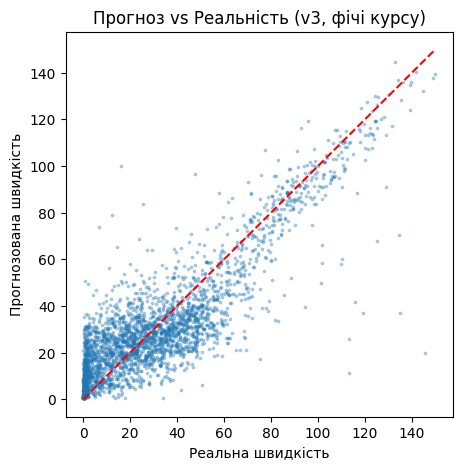

In [43]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test_abs[:3000], y_pred_abs[:3000], s=3, alpha=0.3)
plt.plot([0, MAX_PLAUSIBLE_KMH], [0, MAX_PLAUSIBLE_KMH], 'r--')
plt.xlabel('Реальна швидкість')
plt.ylabel('Прогнозована швидкість')
plt.title('Прогноз vs Реальність (v3, фічі курсу)')
plt.show()

In [44]:
try:
    from sklearn.inspection import permutation_importance
    imp = permutation_importance(model_delta, X_test[:20000], y_delta_test[:20000],
                                  n_repeats=3, random_state=42, n_jobs=-1)
    order = np.argsort(imp.importances_mean)[::-1]
    print('\nВажливість фіч (перевір, що turn-фічі не внизу списку):')
    for i in order:
        print(f'  {FEATURE_NAMES[i]:14s}: {imp.importances_mean[i]:.3f}')
except Exception as e:
    print('Пропускаю permutation importance:', e)


Важливість фіч (перевір, що turn-фічі не внизу списку):
  v5            : 0.409
  d4            : 0.069
  turn4         : 0.062
  v4            : 0.056
  turn3         : 0.035
  d3            : 0.031
  mean_v        : 0.027
  turn2         : 0.024
  std_v         : 0.023
  v3            : 0.019
  mean_abs_turn : 0.018
  turn1         : 0.017
  trend_slope   : 0.014
  max_abs_turn  : 0.011
  v1            : 0.010
  v2            : 0.009
  d2            : 0.007
  d1            : 0.003
  last_turn     : 0.000
  cum_turn      : 0.000


In [ ]:
"""## Крок 9. Тест на "здоровий глузд"

Головна перевірка v3: сценарій "пряма дорога, курс не змінюється" НЕ
повинен більше показувати штучне гальмування.
"""

In [45]:
scenarios = {
    'Пряма, рівна швидкість, курс сталий': ([50, 50, 50, 50, 50], [90, 90, 90, 90, 90]),
    'Пряма з невеликим GPS-шумом курсу':   ([50, 50, 50, 50, 50], [88, 91, 89, 90, 90]),
    'Гальмування перед поворотом':          ([50, 48, 42, 30, 18], [90, 95, 110, 140, 170]),
    'Розгін на прямій':                     ([10, 20, 30, 40, 50], [45, 45, 45, 45, 45]),
    'Плавний поворот на сталій швидкості':  ([40, 40, 40, 40, 40], [0, 20, 40, 60, 80]),
    'Машина стоїть':                        ([0, 0, 0, 0, 0], [90, 90, 90, 90, 90]),
    'Зупинка на світлофорі':                ([30, 20, 10, 5, 0], [90, 90, 90, 90, 90]),
    'Різке гальмування':                    ([80, 75, 60, 30, 10], [90, 92, 90, 91, 90]),
}

In [46]:
print(f"{'Сценарій':42s} | Прогноз       | delta")
print('-' * 75)
for name, (sw, hw) in scenarios.items():
    feats = build_features(sw, hw)
    delta = model_delta.predict([feats])[0]
    pred = sw[-1] + delta
    print(f'{name:42s} | {pred:6.1f} км/год | {delta:+6.1f}')

Сценарій                                   | Прогноз       | delta
---------------------------------------------------------------------------
Пряма, рівна швидкість, курс сталий        |   41.3 км/год |   -8.7
Пряма з невеликим GPS-шумом курсу          |   40.7 км/год |   -9.3
Гальмування перед поворотом                |   21.4 км/год |   +3.4
Розгін на прямій                           |   36.9 км/год |  -13.1
Плавний поворот на сталій швидкості        |   37.5 км/год |   -2.5
Машина стоїть                              |    0.5 км/год |   +0.5
Зупинка на світлофорі                      |    4.0 км/год |   +4.0
Різке гальмування                          |   19.3 км/год |   +9.3


In [ ]:
"""## Крок 10. Зберігаємо модель + feature_utils.py для Маші

**Важлива зміна для сервера:** `build_features` тепер приймає ДВА
буфери — останні 5 швидкостей і останні 5 курсів (`heading` з ваших
UDP-пакетів). Замінити виклик на сервері треба відповідно.
"""

In [47]:
joblib.dump(model_delta, 'model.pkl')

['model.pkl']

In [49]:
feature_utils_code = '''\
"""Функція побудови фіч для моделі прогнозу швидкості (v3, з курсом).
Використовувати ІДЕНТИЧНО до того, як рахувалось при тренуванні —
інакше model.predict() дасть сміттєвий результат.

Модель повертає ДЕЛЬТУ швидкості (км/год), не абсолютне значення:
    predicted_speed = last_speed + model.predict([features])[0]
"""
import numpy as np

MIN_SPEED_FOR_HEADING_KMH = 3.0

FEATURE_NAMES = [
    "v1", "v2", "v3", "v4", "v5",
    "d1", "d2", "d3", "d4",
    "mean_v", "std_v", "trend_slope",
    "turn1", "turn2", "turn3", "turn4",
    "mean_abs_turn", "max_abs_turn",
    "cum_turn", "last_turn",
]


def angle_diff(a2, a1):
    """Різниця кутів у діапазоні [-180, 180]."""
    return (a2 - a1 + 180) % 360 - 180


def build_features(speed_window, heading_window):
    """speed_window, heading_window: по 5 останніх значень
    (від найстарішого до найновішого). heading_window бери з поля
    "heading" останніх 5 UDP-пакетів. Повертає список з 20 чисел
    у порядку FEATURE_NAMES.
    """
    sw = list(speed_window)
    hw = list(heading_window)

    diffs = [sw[i + 1] - sw[i] for i in range(len(sw) - 1)]
    mean_v = float(np.mean(sw))
    std_v = float(np.std(sw))
    trend_slope = float(np.polyfit(range(len(sw)), sw, 1)[0])

    turns = []
    for i in range(len(hw) - 1):
        if sw[i] < MIN_SPEED_FOR_HEADING_KMH or sw[i + 1] < MIN_SPEED_FOR_HEADING_KMH:
            turns.append(0.0)
        else:
            turns.append(angle_diff(hw[i + 1], hw[i]))

    abs_turns = [abs(t) for t in turns]
    mean_abs_turn = float(np.mean(abs_turns))
    max_abs_turn = float(np.max(abs_turns))
    cum_turn = float(np.sum(abs_turns))
    last_turn = float(turns[-1])

    return sw + diffs + [mean_v, std_v, trend_slope] + turns + [
        mean_abs_turn, max_abs_turn, cum_turn, last_turn
    ]
'''

In [50]:
with open('feature_utils.py', 'w', encoding='utf-8') as f:
    f.write(feature_utils_code)

In [51]:
metadata = {
    'version': 'v3_heading',
    'input_format': (
        'build_features(speed_window, heading_window) з feature_utils.py, '
        'де обидва вікна — останні 5 значень (км/год і градуси азимута)'
    ),
    'input_shape': [1, len(FEATURE_NAMES)],
    'feature_names': FEATURE_NAMES,
    'output_format': (
        'дельта швидкості (км/год) на наступному кроці (крок = 15 сек); '
        'абсолютна швидкість = остання відома швидкість + delta'
    ),
    'usage_example': (
        'from feature_utils import build_features; '
        'delta = model.predict([build_features([50,48,42,30,18], [90,95,110,140,170])])[0]; '
        'predicted_speed = 18 + delta'
    ),
    'required_libs': ['scikit-learn', 'joblib', 'numpy'],
    'model_type': 'HistGradientBoostingRegressor (tuned, delta target, heading features)',
    'best_params': search.best_params_,
    'val_mae_kmh': round(float(mae), 2),
    'val_rmse_kmh': round(float(rmse), 2),
    'val_r2': round(float(r2), 3),
    'trained_on_rows': int(X.shape[0]),
    'notes': (
        'Модель прогнозує на 15 сек вперед (SAMPLE_INTERVAL_SEC у тренуванні). '
        'Якщо сервер оновлює позицію щосекунди — інтерполюй лінійно між поточною '
        'і прогнозованою швидкістю на 15 кроків, а не викликай модель щосекунди.'
    ),
}
with open('model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

In [52]:
print('Збережено: model.pkl, feature_utils.py, model_metadata.json')

Збережено: model.pkl, feature_utils.py, model_metadata.json


In [53]:
files.download('model.pkl')
files.download('feature_utils.py')
files.download('model_metadata.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
"""## Крок 11. Фінальна перевірка — так, як буде у Маші на сервері"""

In [54]:
import importlib.util

In [55]:
spec = importlib.util.spec_from_file_location('feature_utils', 'feature_utils.py')
fu = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fu)

In [56]:
loaded_model = joblib.load('model.pkl')

In [57]:
test_speed_buffer = [50, 50, 50, 50, 50]
test_heading_buffer = [90, 90, 90, 90, 90]
feats = fu.build_features(test_speed_buffer, test_heading_buffer)
delta = loaded_model.predict([feats])[0]
prediction = test_speed_buffer[-1] + delta

In [58]:
print(f'Швидкості: {test_speed_buffer}')
print(f'Курси:     {test_heading_buffer}')
print(f'Прогноз наступної швидкості: {prediction:.1f} км/год (delta={delta:+.1f})')
print('\\nЯкщо число близьке до 50, а не сильно нижче — фікс спрацював.')

Швидкості: [50, 50, 50, 50, 50]
Курси:     [90, 90, 90, 90, 90]
Прогноз наступної швидкості: 41.3 км/год (delta=-8.7)
\nЯкщо число близьке до 50, а не сильно нижче — фікс спрацював.


In [59]:
"""## Що передати Маші

Три файли разом: `model.pkl`, `feature_utils.py`, `model_metadata.json`.

На сервері:
```python
import joblib
from feature_utils import build_features

model = joblib.load('model.pkl')

speed_buffer = [50, 48, 42, 30, 18]     # останні 5 speed з UDP-пакетів
heading_buffer = [90, 95, 110, 140, 170]  # останні 5 heading з тих самих пакетів

delta = model.predict([build_features(speed_buffer, heading_buffer)])[0]
predicted_speed = speed_buffer[-1] + delta
```

**Два важливі нюанси для інтеграції:**
1. Модель прогнозує на 15 секунд вперед (як і дані для тренування), а не
   на 1 секунду. Якщо dead-reckoning цикл на сервері оновлює позицію
   щосекунди — виклич модель один раз на початку "сліпого" періоду й далі
   лінійно інтерполюй швидкість від поточної до прогнозованої по 15 кроках,
   а не виклик моделі кожну секунду з тим самим вікном.
2. `heading` бери прямо з поля пакета, а не рахуй заново — так дані на
   сервері і при тренуванні матимуть однакову природу (напрямок руху,
   а не помилково — компас/орієнтація кузова, якщо раптом є різниця).
"""

'## Що передати Маші\n\nТри файли разом: `model.pkl`, `feature_utils.py`, `model_metadata.json`.\n\nНа сервері:\n```python\nimport joblib\nfrom feature_utils import build_features\n\nmodel = joblib.load(\'model.pkl\')\n\nspeed_buffer = [50, 48, 42, 30, 18]     # останні 5 speed з UDP-пакетів\nheading_buffer = [90, 95, 110, 140, 170]  # останні 5 heading з тих самих пакетів\n\ndelta = model.predict([build_features(speed_buffer, heading_buffer)])[0]\npredicted_speed = speed_buffer[-1] + delta\n```\n\n**Два важливі нюанси для інтеграції:**\n1. Модель прогнозує на 15 секунд вперед (як і дані для тренування), а не\n   на 1 секунду. Якщо dead-reckoning цикл на сервері оновлює позицію\n   щосекунди — виклич модель один раз на початку "сліпого" періоду й далі\n   лінійно інтерполюй швидкість від поточної до прогнозованої по 15 кроках,\n   а не виклик моделі кожну секунду з тим самим вікном.\n2. `heading` бери прямо з поля пакета, а не рахуй заново — так дані на\n   сервері і при тренуванні мат